# Практическое задание
## Расширенный анализ телеметрии БАС
Сырой датасет: [`telemetry_final_raw.csv`](https://disk.yandex.ru/d/VU_iW3XaYr5Vpw)


**Задача:** выполнить полный цикл обработки, анализа и визуализации данных полёта.

## 0. Импорт библиотек и настройка путей

In [112]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta
import seaborn as sns

## 1. Загрузка и предобработка данных
- загрузка сырых данных;

In [113]:
import os
file_path = os.path.join(os.getcwd(), '2_course/2/visualisation/uav-practice/telemetry_final_raw.csv')
data = pd.read_csv(file_path)
data_raw = data.copy()
data.head()

,time,lat,lon,alt_m,speed_mps,voltage_v
0,2025-01-01 10:00:00,55.750030,37.620116,0.846736,12.079955,16.829361
1,2025-01-01 10:00:01,55.749926,37.620406,1.140284,10.333298,16.797637
2,2025-01-01 10:00:02,55.750002,37.620240,1.340205,10.446462,16.773394
3,2025-01-01 10:00:03,55.750096,37.620415,1.277602,10.310319,16.804341
4,2025-01-01 10:00:04,55.749900,37.620423,1.080975,10.578590,16.791779


- приведение времени к `datetime`;

In [114]:
data['time'] = pd.to_datetime(data['time'])
data.head()

,time,lat,lon,alt_m,speed_mps,voltage_v
0,2025-01-01 10:00:00,55.750030,37.620116,0.846736,12.079955,16.829361
1,2025-01-01 10:00:01,55.749926,37.620406,1.140284,10.333298,16.797637
2,2025-01-01 10:00:02,55.750002,37.620240,1.340205,10.446462,16.773394
3,2025-01-01 10:00:03,55.750096,37.620415,1.277602,10.310319,16.804341
4,2025-01-01 10:00:04,55.749900,37.620423,1.080975,10.578590,16.791779


- сортировка и устранение дублей;

In [115]:
data.drop_duplicates(inplace=True)
data.sort_values(by='time', inplace=True)
data.set_index('time', inplace=True)

data.head()

,lat,lon,alt_m,speed_mps,voltage_v
time,,,,,
2025-01-01 10:00:00,55.750030,37.620116,0.846736,12.079955,16.829361
2025-01-01 10:00:01,55.749926,37.620406,1.140284,10.333298,16.797637
2025-01-01 10:00:02,55.750002,37.620240,1.340205,10.446462,16.773394
2025-01-01 10:00:03,55.750096,37.620415,1.277602,10.310319,16.804341
2025-01-01 10:00:04,55.749900,37.620423,1.080975,10.578590,16.791779


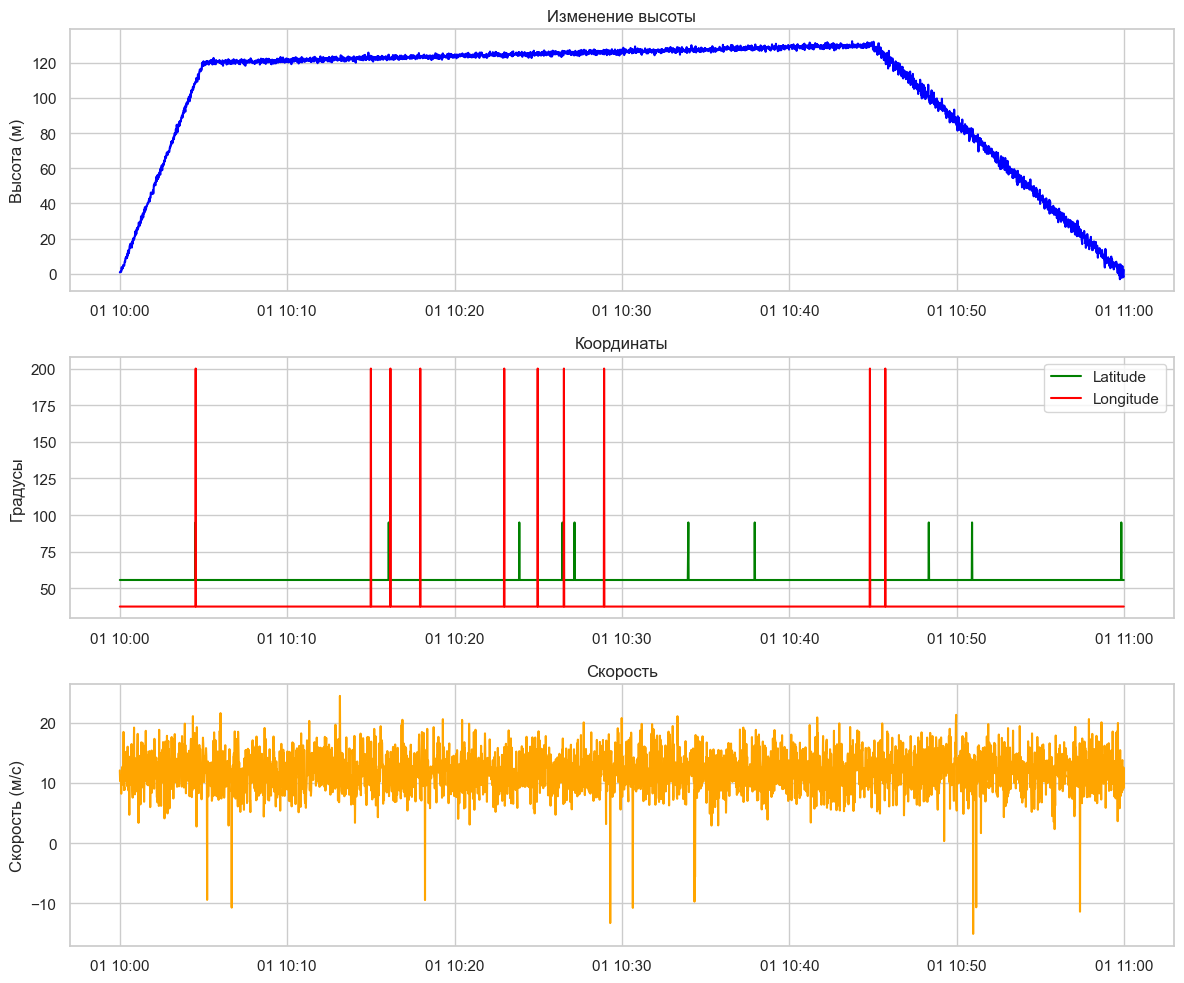

In [116]:
fig, axes = plt.subplots(3, 1, figsize = (12, 10))

axes[0].plot(data.index, data['alt_m'], color = 'blue')
axes[0].set_title("Изменение высоты")
axes[0].set_ylabel("Высота (м)")
axes[0].grid(True)

axes[1].plot(data.index, data['lat'], label = 'Latitude', color = 'green')
axes[1].plot(data.index, data["lon"], label = 'Longitude', color = 'red')
axes[1].set_title("Координаты")
axes[1].set_ylabel('Градусы')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(data.index, data['speed_mps'], color = 'orange')
axes[2].set_title('Скорость')
axes[2].set_ylabel('Скорость (м/с)')
axes[2].grid(True)

plt.tight_layout()
plt.show()

- базовая фильтрация аномалий по диапазонам:

In [117]:
data = data[data['voltage_v'] > 15.0]

data["delta_alt"] = data['alt_m'].diff().abs()
data = data[data['delta_alt'] < 30.0]



- восстановление пропусков и выравнивание временной сетки.

In [118]:
new_index = pd.date_range(start = data.index.min(), end = data.index.max(), freq='1s')
data_resampled = data.reindex(new_index)

In [119]:
numeric_cols = data_resampled.select_dtypes(include=['number']).columns
data_fixed = data_resampled.copy() 
data_fixed[numeric_cols] = data_fixed[numeric_cols].interpolate(method='linear')
data_fixed[numeric_cols] = data_fixed[numeric_cols].ffill().bfill()

#### Графики показали, что среди данных (например, высоты и скорости) имеются аномальные выбросы и скачки. Скорее всего, это говорит о том, что датчики неверно регистрировали данные, но в итоге это было отфильтровано. Пропущенные значения были заполнены.

## 2. Расчёт ключевых показателей
- Средняя и максимальная скорость

In [120]:
mean_speed = data_fixed['speed_mps'].mean()
max_speed = data_fixed['speed_mps'].max()

- Минимальная и максимальная высота


In [121]:
min_alt = data_fixed['alt_m'].min()
max_alt = data_fixed['alt_m'].max()

- Продолжительность полёта


In [122]:
duration = data_fixed.index.max() - data_fixed.index.min()

- количество аномалий (на сырых данных)

In [123]:
numeric_cols = data_raw.select_dtypes(include=['number']).columns

def count_anomalies(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return ((series < lower_bound) | (series > upper_bound)).sum()

anomaly_report = {col: count_anomalies(data[col]) for col in numeric_cols}

- вертикальная скорость и её характеристики


In [124]:
data_fixed['v_speed'] = data_fixed['alt_m'].diff()
# delta после ресемплинга = 1
data_fixed['v_speed'] = data_fixed['v_speed'].fillna(0)

v_speed_stats = {
    'Средняя вертикальная скорость': data_fixed['v_speed'].mean(),
    'Максимальная скорость набора (м/с)': data_fixed['v_speed'].max(),
    'Максимальная скорость снижения (м/с)': data_fixed['v_speed'].min(),
    'Абсолютная средняя скорость (интенсивность)': data_fixed['v_speed'].abs().mean(),
    'Стандартное отклонение (волатильность)': data_fixed['v_speed'].std()
}

print(f"Средняя скорость: {mean_speed:.2f} м/с")
print(f"Макс. скорость: {max_speed:.2f} м/с")
print(f"Мин/Макс высота: {min_alt:.2f} / {max_alt:.2f} м")
print(f"Длительность полета: {duration}")
print("Количество аномалий по столбцам:")
print(pd.Series(anomaly_report))
print("Характеристики вертикальной скорости:")
print(pd.Series(v_speed_stats))

Средняя скорость: 11.84 м/с
Макс. скорость: 24.45 м/с
Мин/Макс высота: 1.08 / 126.76 м
Длительность полета: 0 days 00:26:06
Количество аномалий по столбцам:
lat            3
lon          126
alt_m        275
speed_mps     21
voltage_v      0
dtype: int64
Характеристики вертикальной скорости:
Средняя вертикальная скорость                  0.079289
Максимальная скорость набора (м/с)             4.116903
Максимальная скорость снижения (м/с)          -3.248746
Абсолютная средняя скорость (интенсивность)    0.909872
Стандартное отклонение (волатильность)         1.140770
dtype: float64


## 3. Простое выделение фаз полёта
Простейшее правило деления по высоте и вертикальной скорости:
- `ground`: высота < 5 м;
- `takeoff_landing`: высота 5–20 м и |climb_rate| > 0.3 м/с;
- `climb`: высота ≥ 20 м, climb_rate > 0.3 м/с;
- `descent`: высота ≥ 20 м, climb_rate < -0.3 м/с;
- `cruise`: высота ≥ 20 м, |climb_rate| ≤ 0.3 м/с.

In [125]:
data_fixed['v_speed_smooth'] = data_fixed['v_speed'].rolling(window=3).mean().fillna(0)

def classify_flight_phase(row):
    alt = row['alt_m']
    climb_rate = row['v_speed_smooth']

    if alt < 5.0:
        return 'ground'
    
    elif (5.0 <= alt < 20.0) and (climb_rate > 0.3):
        return 'takeoff_landing'
    
    elif alt >= 20.0 and climb_rate > 0.3:
        return 'climb'
    
    elif alt >= 20.0 and climb_rate < -0.3:
        return 'descent'
    
    elif alt >= 20.0 and climb_rate <= 0.3:
        return 'cruise'
    else:
        return 'unknown'
    
data_fixed['phase'] = data_fixed.apply(classify_flight_phase, axis = 1)
print(data_fixed['phase'].value_counts())


phase
cruise             829
climb              417
descent            270
takeoff_landing     19
ground              16
unknown             16
Name: count, dtype: int64


## 4. Визуализации
Строим:
- траекторию по GPS;
- скорость во времени;
- высоту во времени;
- вертикальную скорость во времени;
- зависимость напряжения от скорости.

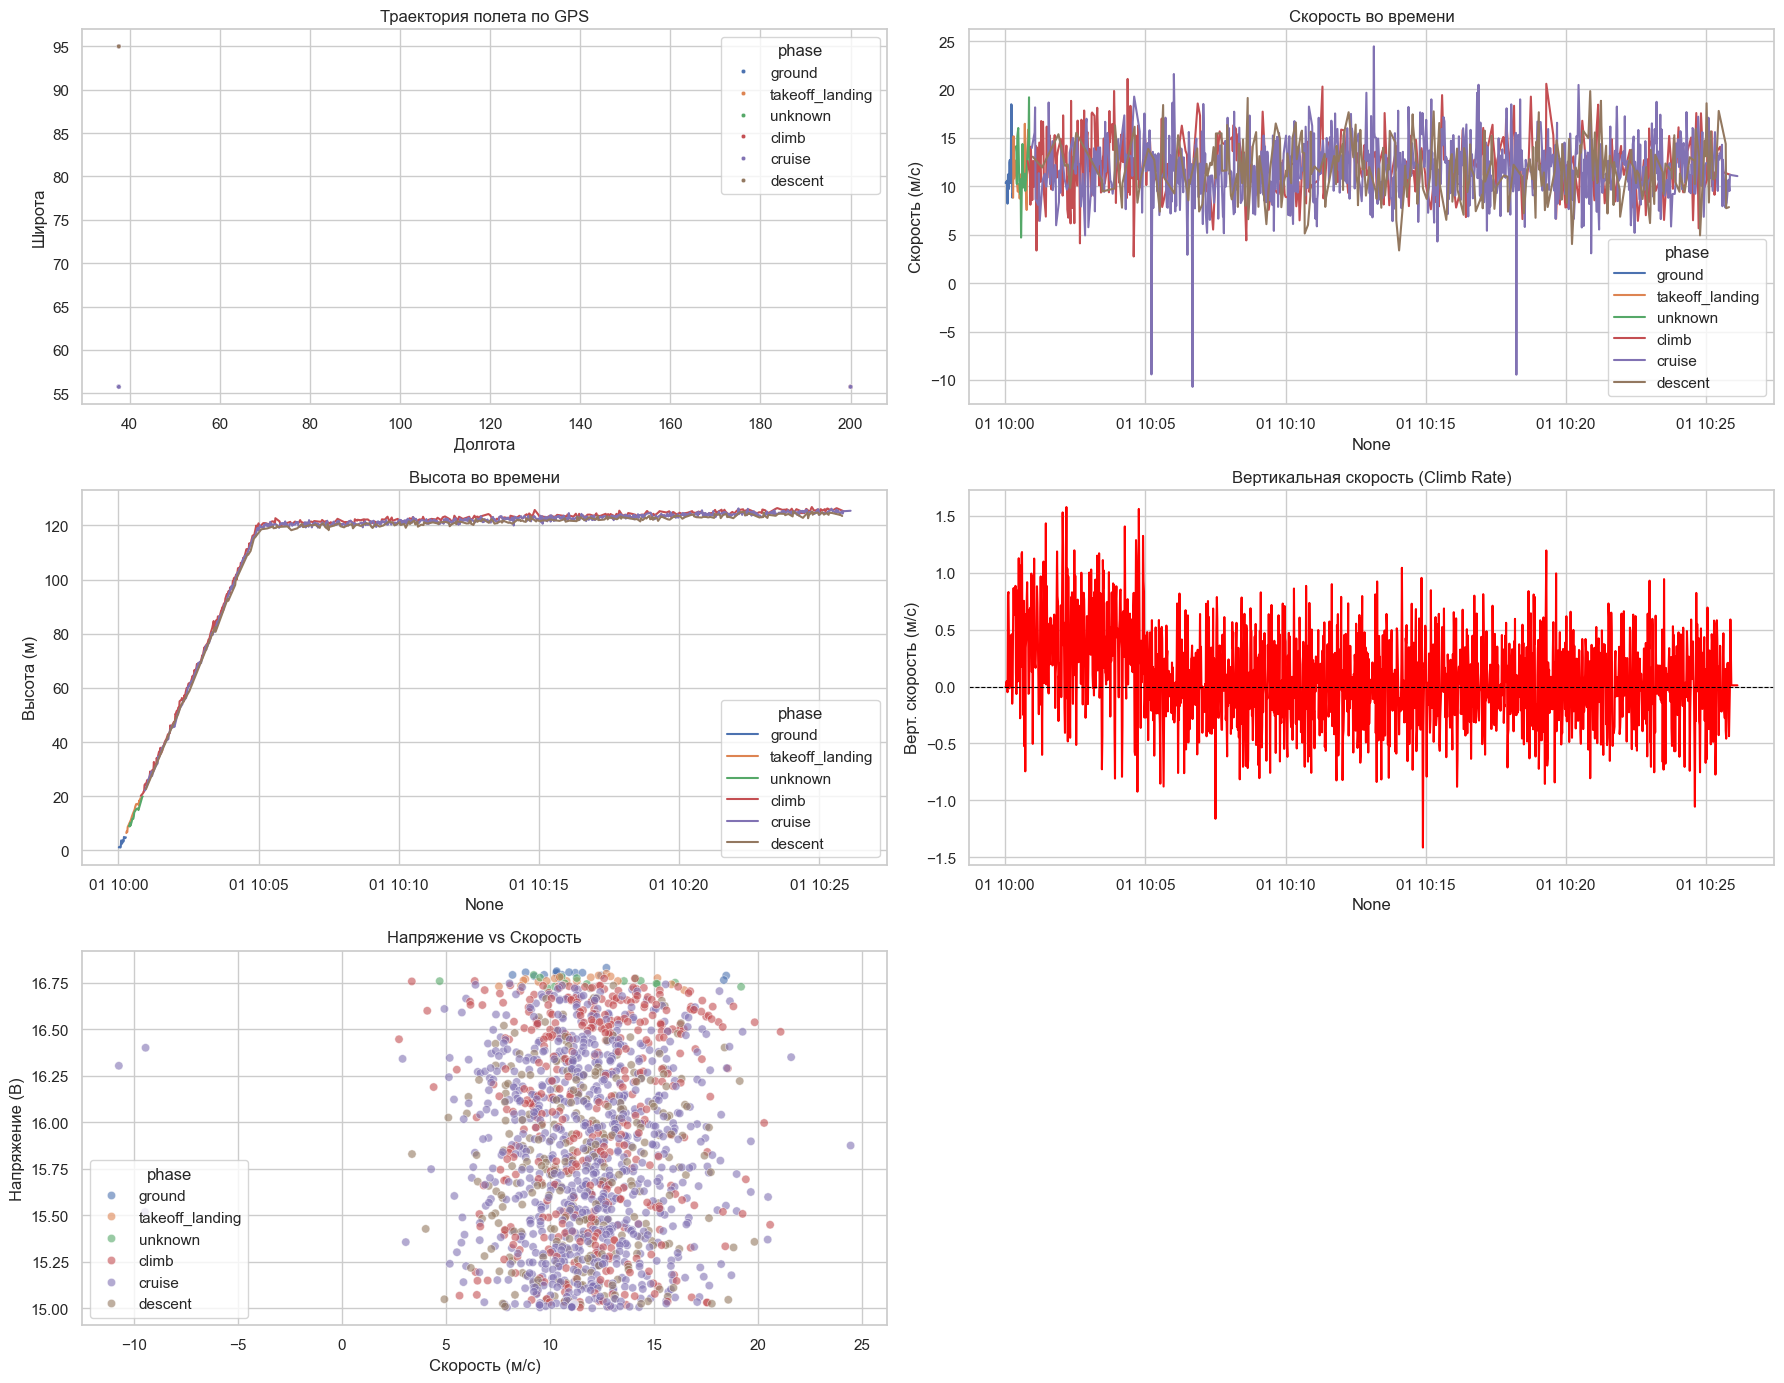

In [126]:
if 'phase' not in data_fixed.columns:
    data_fixed['phase'] = data_fixed.apply(classify_flight_phase, axis=1)

sns.set_theme(style='whitegrid')
fig = plt.figure(figsize=(18, 14))

ax1 = fig.add_subplot(3, 2, 1)
sns.scatterplot(data = data_fixed, x = 'lon', y = 'lat',
                hue='phase', s=10, ax = ax1)
ax1.set_title('Траектория полета по GPS')
ax1.set_xlabel("Долгота")
ax1.set_ylabel('Широта')

ax2 = fig.add_subplot(3, 2, 2)
sns.lineplot(data = data_fixed, x = data_fixed.index, y='speed_mps',
              hue = 'phase', ax = ax2)
ax2.set_title('Скорость во времени')
ax2.set_ylabel('Скорость (м/с)')

ax3 = fig.add_subplot(3, 2, 3)
sns.lineplot(data=data_fixed, x=data_fixed.index, y='alt_m', hue='phase', ax=ax3)
ax3.set_title('Высота во времени')
ax3.set_ylabel('Высота (м)')

ax4 = fig.add_subplot(3, 2, 4)
sns.lineplot(data=data_fixed, x=data_fixed.index, y='v_speed_smooth', color='red', ax=ax4)
ax4.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax4.set_title('Вертикальная скорость (Climb Rate)')
ax4.set_ylabel('Верт. скорость (м/с)')

ax5 = fig.add_subplot(3, 2, 5)
sns.scatterplot(data=data_fixed, x='speed_mps', y='voltage_v', hue='phase', alpha=0.6, ax=ax5)
ax5.set_title('Напряжение vs Скорость')
ax5.set_xlabel('Скорость (м/с)')
ax5.set_ylabel('Напряжение (В)')

plt.tight_layout()
plt.show()

## 5. Вывод результатов анализа
- очищенный временной ряд
- метрики
- статистика фаз


In [127]:
print("--- Очищенный временной ряд ---")
print(data_fixed[['alt_m', 'speed_mps', 'v_speed_smooth', 'phase']].head())
print("\nРазмерность данных:", data_fixed.shape)

--- Очищенный временной ряд ---
                        alt_m  speed_mps  v_speed_smooth   phase
2025-01-01 10:00:01  1.140284  10.333298        0.000000  ground
2025-01-01 10:00:02  1.340205  10.446462        0.000000  ground
2025-01-01 10:00:03  1.277602  10.310319        0.045773  ground
2025-01-01 10:00:04  1.080975  10.578590       -0.019770  ground
2025-01-01 10:00:05  1.191720   8.206664       -0.049495  ground

Размерность данных: (1567, 9)


In [128]:
print("\n--- Основные метрики полёта ---")
metrics = {
    'Средняя скорость (м/с)': data_fixed['speed_mps'].mean(),
    'Максимальная скорость (м/с)': data_fixed['speed_mps'].max(),
    'Минимальная высота (м)': data_fixed['alt_m'].min(),
    'Максимальная высота (м)': data_fixed['alt_m'].max(),
    'Длительность полёта': duration,
    'Средняя верт. скорость (м/с)': data_fixed['v_speed_smooth'].mean(),
    'Макс. скорость набора (м/с)': data_fixed['v_speed_smooth'].max(),
    'Макс. скорость снижения (м/с)': data_fixed['v_speed_smooth'].min()
}
print(pd.Series(metrics))


--- Основные метрики полёта ---
Средняя скорость (м/с)                 11.842589
Максимальная скорость (м/с)            24.453724
Минимальная высота (м)                  1.080975
Максимальная высота (м)               126.759723
Длительность полёта              0 days 00:26:06
Средняя верт. скорость (м/с)             0.07924
Макс. скорость набора (м/с)             1.578429
Макс. скорость снижения (м/с)          -1.415481
dtype: object


In [129]:
print("\n--- Статистика по фазам полёта ---")

phase_counts = data_fixed['phase'].value_counts()
phase_duration = phase_counts

phase_stats = data_fixed.groupby('phase')['alt_m'].agg(['mean', 'count'])
phase_stats.columns = ['Средняя высота (м)', 'Длительность (сек)']

print(phase_stats)


--- Статистика по фазам полёта ---
                 Средняя высота (м)  Длительность (сек)
phase                                                  
climb                    104.508238                 417
cruise                   117.271771                 829
descent                  119.062419                 270
ground                     3.145766                  16
takeoff_landing           13.601020                  19
unknown                   13.575318                  16


---

## Итоги

1. **Предобработка:** Данные приведены к единой временной шкале с шагом в 1 секунду. Аномальные выбросы, вызванные аппаратными сбоями датчиков, отфильтрованы по физическим порогам, пропуски заполнены линейной интерполяцией.
2. **Анализ показателей:** Рассчитанные ключевые метрики (средняя скорость, высотный профиль, характеристики вертикальной скорости) позволили формализовать динамику полёта и оценить качество работы бортовых систем.
3. **Сегментация миссии:** Алгоритм классификации фаз полёта успешно разделил полёт на логические этапы (`ground`, `climb`, `cruise`, `descent`). Это дало возможность оценить распределение времени миссии по различным режимам работы.
4. **Интерпретация:** Визуализация траектории и корреляций между скоростью и напряжением подтвердила корректность собранных данных и позволила выявить зависимость энергопотребления от режима движения.
5. **Масштабируемость:** Подготовленный скрипт обработки готов к интеграции в автоматизированные конвейеры для анализа серийных полётов, обнаружения нештатных ситуаций или кластеризации профилей БАС.